In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
with open('configs/50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [3]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.2
1
16
32
10
50000


In [9]:
#calculate pseudo-scalar mass for this lattice
bIn = 1000
skp = 50
correl = sim.distillation.correlStats(temp, burnIn=bIn,autocorrSkip=skp,nVec=2)
piv = 4
mass = sim.distillation.correlMassExtract(correl,fitT=[piv,15],diagCov=False)
mass

configs:   0%|          | 0/980 [00:00<?, ?it/s]

array([0.55810792, 0.00072378])

In [19]:
bIn = 500
skp = 100
mus = np.linspace(0,2.75*mass[0],50)

densities = Parallel(n_jobs=-1)(delayed(sim.analysis.numDensityStats)(temp,burnIn=bIn,autocorrSkip=skp, chemicalPot=mu) for mu in mus)

100%|██████████| 495/495 [03:03<00:00,  2.70it/s]


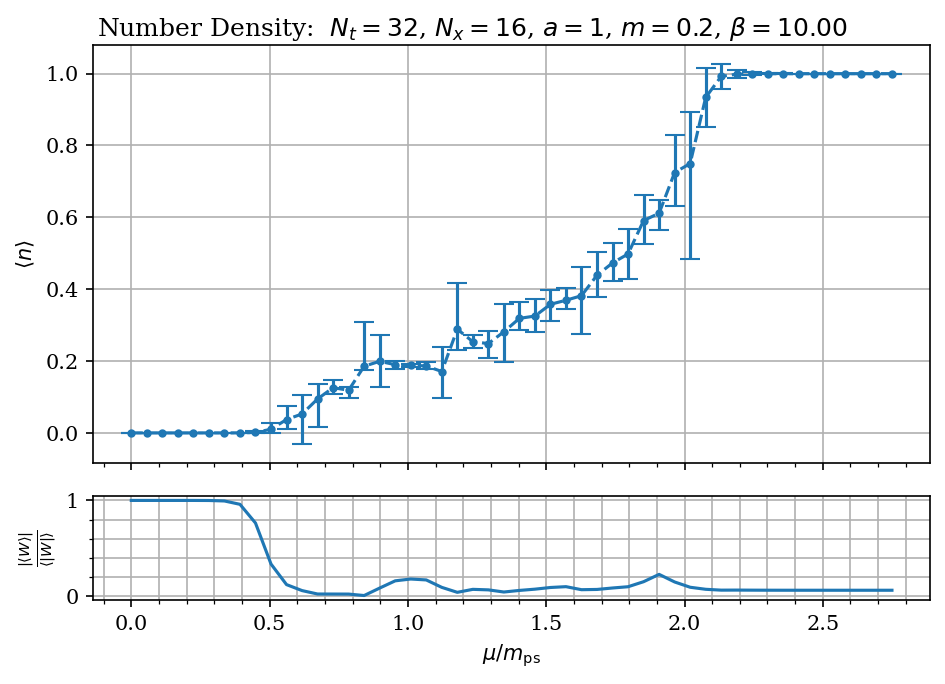

In [21]:
dens = np.array([densities[i][0] for i in range(len(densities))])
densErr = np.array([densities[i][1] for i in range(len(densities))]).T
validity = np.array([densities[i][2] for i in range(len(densities))])

fig, ax = plt.subplots(dpi=150, nrows=2, height_ratios=[4,1],sharex=True)

ax[0].errorbar(x=mus/mass[0],y=temp.a*dens,yerr=np.abs(densErr),capsize=5, marker=".",ls="--")
ax[0].set_ylabel(r"$\langle n\rangle$")
ax[0].grid()
ax[1].set_xlabel(r"$\mu/m_\text{ps}$")

ax[1].plot(mus/mass[0],validity)
ax[1].set_ylabel(r"$\frac{|\langle W\rangle|}{\langle |W| \rangle}$")
ax[1].minorticks_on()
ax[1].grid(which="both")

fig.suptitle(rf"Number Density:  $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta:.2f}$",y=.94)
plt.tight_layout()